In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

In [2]:
results_df = pd.read_csv('../data_clean/simulation_results.csv')
params_df  = pd.read_csv('../data_clean/simulation_parameters.csv')
regions_gdf = gpd.read_file('../data_clean/regions_clean.gpkg')

print('Results loaded:', results_df.shape)
print('Parameters loaded:', params_df.shape)
print('Regions loaded:', len(regions_gdf))

Results loaded: (51, 6)
Parameters loaded: (51, 8)
Regions loaded: 17


Stacked bar chart of risk profiles

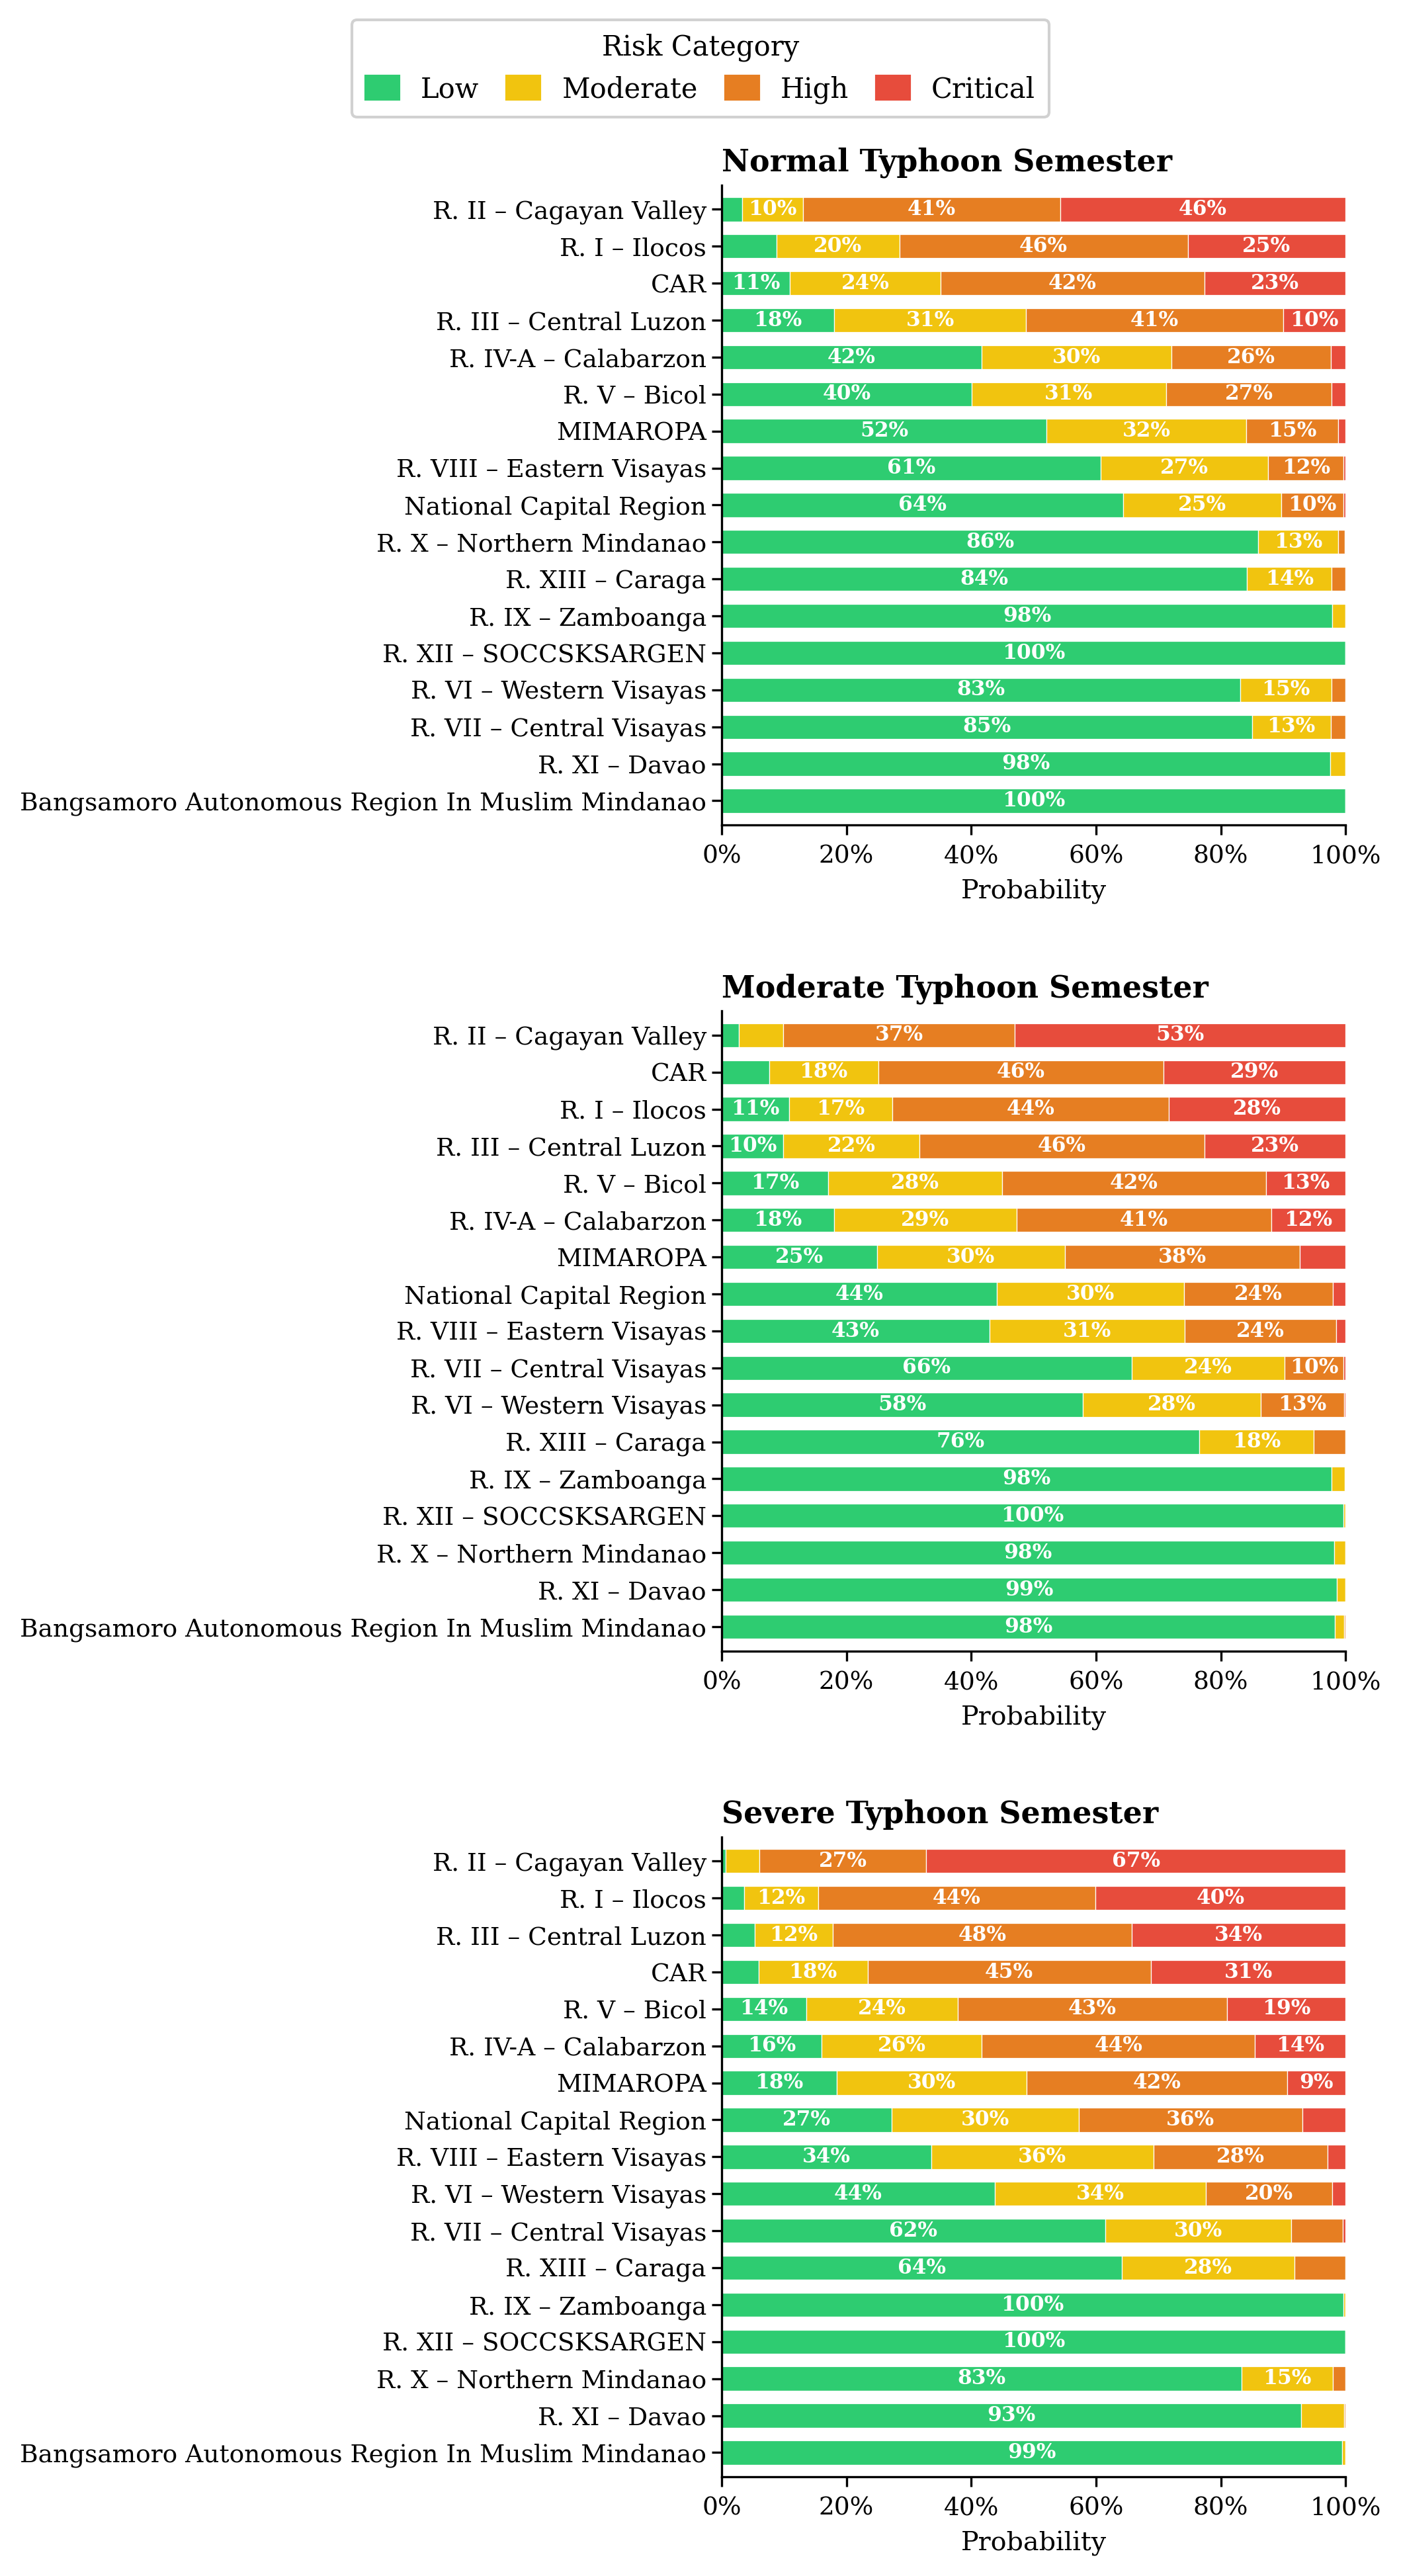

In [20]:

SCENARIOS   = ['Normal', 'Moderate', 'Severe']
RISK_COLS   = ['p_low', 'p_moderate', 'p_high', 'p_critical']
RISK_LABELS = ['Low', 'Moderate', 'High', 'Critical']
COLORS      = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

short_names = {
    "Region II (Cagayan Valley)":                          "R. II – Cagayan Valley",
    "Region I (Ilocos Region)":                            "R. I – Ilocos",
    "Cordillera Administrative Region (CAR)":              "CAR",
    "Region III (Central Luzon)":                          "R. III – Central Luzon",
    "Region V (Bicol Region)":                             "R. V – Bicol",
    "Region IV-A (Calabarzon)":                            "R. IV-A – Calabarzon",
    "Mimaropa Region":                                     "MIMAROPA",
    "Region VIII (Eastern Visayas)":                       "R. VIII – Eastern Visayas",
    "Region VII (Central Visayas)":                        "R. VII – Central Visayas",
    "National Capital Region":                             "NCR",
    "Region XIII (Caraga)":                                "R. XIII – Caraga",
    "Region IX (Zamboanga Peninsula)":                     "R. IX – Zamboanga",
    "Region XII (Soccsksargen)":                           "R. XII – SOCCSKSARGEN",
    "Region VI (Western Visayas)":                         "R. VI – Western Visayas",
    "Region X (Northern Mindanao)":                        "R. X – Northern Mindanao",
    "Region XI (Davao Region)":                            "R. XI – Davao",
    "Bangsamoro Autonomous Region In Muslim Mindanao":     "BARMM",
}

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
})

fig, axes = plt.subplots(3, 1, figsize=(7.16, 12.5), dpi=300)

for ax, scenario in zip(axes, SCENARIOS):
    data = (
        results_df[results_df['scenario'] == scenario]
        .copy()
        .sort_values('p_critical', ascending=True)
        .reset_index(drop=True)
    )

    data['short'] = data['region'].map(short_names).fillna(
        data['region'].str.replace(r'\(.*?\)', '', regex=True).str.strip()
    )

    bottoms = np.zeros(len(data))

    for col, label, color in zip(RISK_COLS, RISK_LABELS, COLORS):
        values = data[col].values
        ax.barh(
            data['short'], values,
            left=bottoms,
            color=color,
            label=label,
            height=0.65,
            edgecolor='white',
            linewidth=0.3
        )
        for i, (val, bot) in enumerate(zip(values, bottoms)):
            if val >= 0.09:
                ax.text(
                    bot + val / 2, i,
                    f'{val:.0%}',
                    ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold'
                )
        bottoms += values

    ax.set_title(
        f'{scenario} Typhoon Semester',
        fontsize=11, fontweight='bold', pad=5, loc='left'
    )
    ax.set_xlabel('Probability', fontsize=9.5)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(axis='y', labelsize=9, pad=2)
    ax.tick_params(axis='x', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(y=0.02)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(COLORS, RISK_LABELS)
]
fig.legend(
    handles=legend_patches,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    fontsize=10,
    framealpha=0.9,
    handlelength=1.2,
    handleheight=0.9,
    columnspacing=1.0,
    borderpad=0.5,
    title='Risk Category',
    title_fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.995], h_pad=2.5)
plt.savefig(
    '../results/01_risk_profile_stacked_bar.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

Choropleth Dominant Risk Map (Single Severe + Three-scenario comparison)

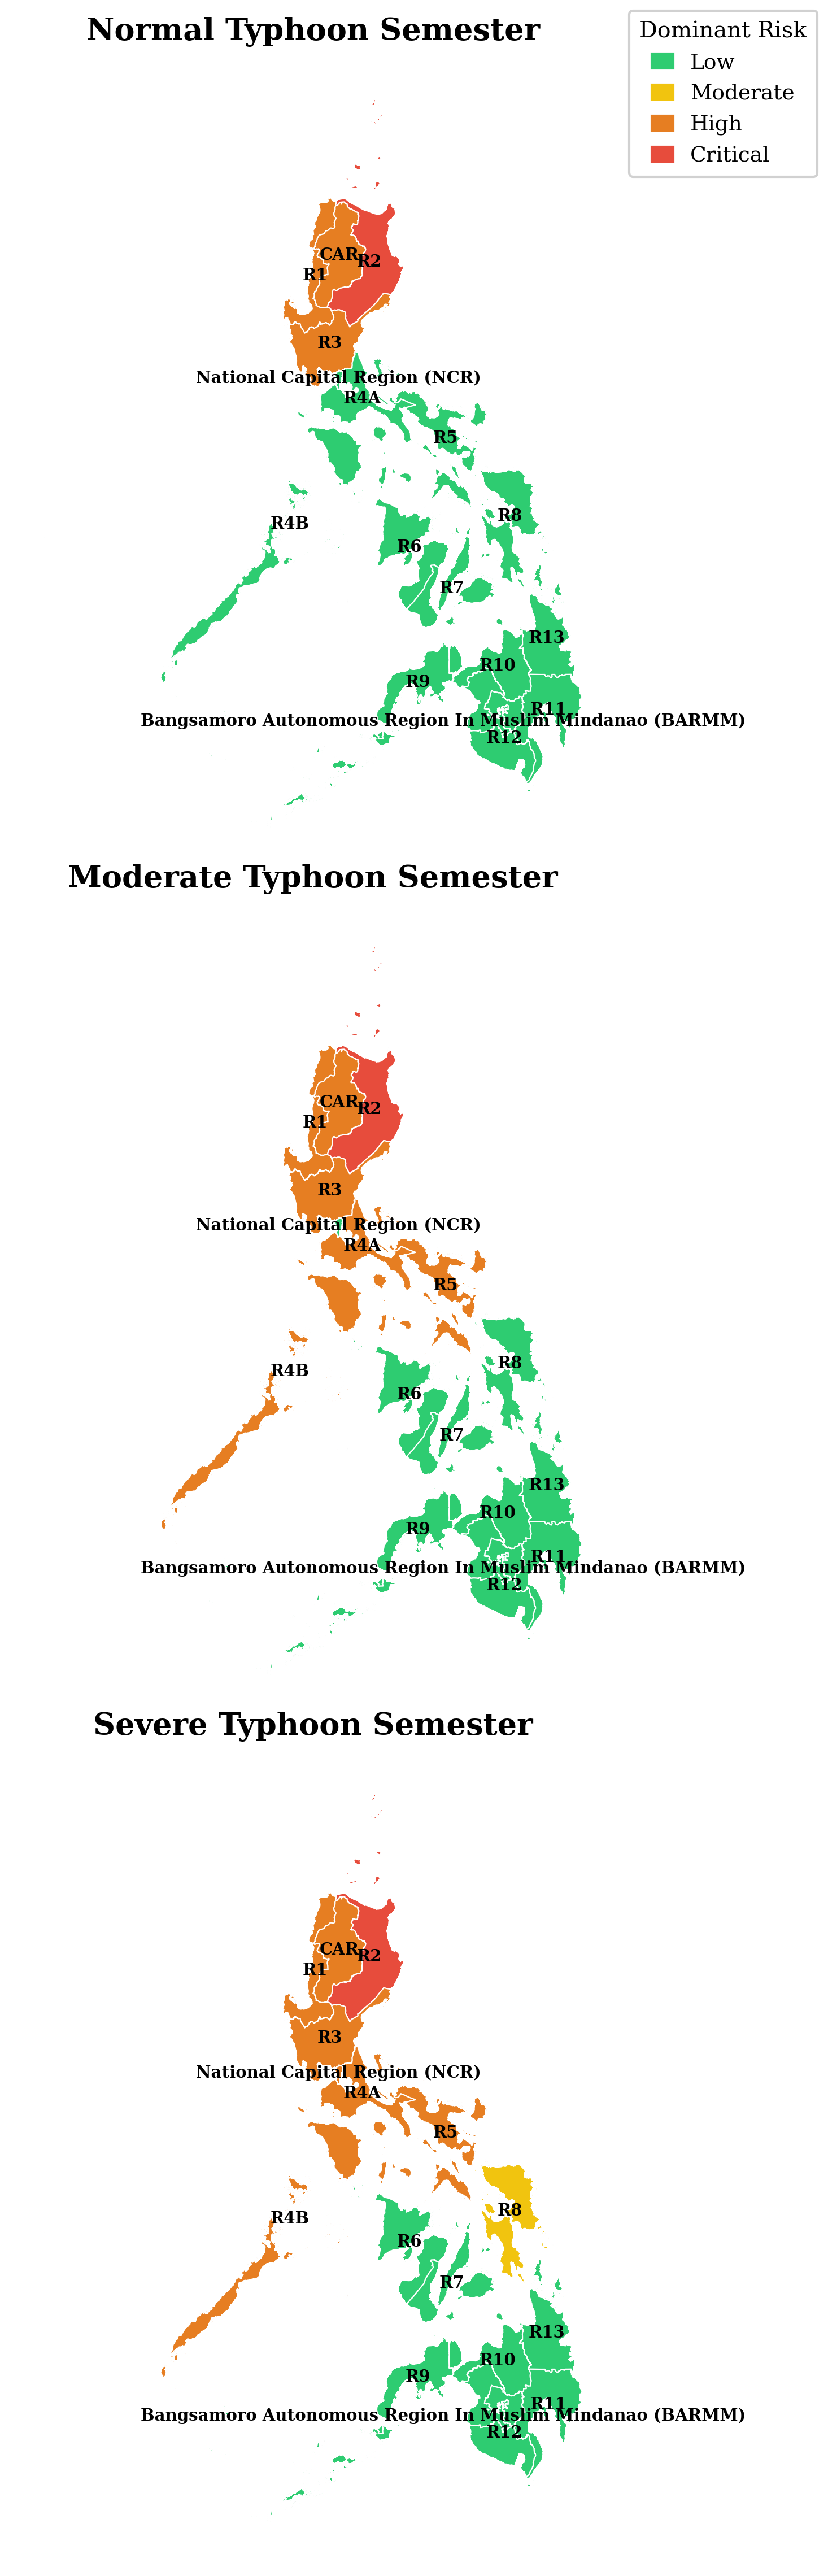

In [ ]:
RISK_COLORS = {
    'Low':      '#2ecc71',
    'Moderate': '#f1c40f',
    'High':     '#e67e22',
    'Critical': '#e74c3c'
}
RISK_ORDER = ['Low', 'Moderate', 'High', 'Critical']

REGION_ABBREV = {
    'Region I (Ilocos Region)':                            'R1',
    'Region II (Cagayan Valley)':                          'R2',
    'Region III (Central Luzon)':                          'R3',
    'Region IV-A (Calabarzon)':                            'R4A',
    'Mimaropa Region':                                     'R4B',
    'Region V (Bicol Region)':                             'R5',
    'Region VI (Western Visayas)':                         'R6',
    'Region VII (Central Visayas)':                        'R7',
    'Region VIII (Eastern Visayas)':                       'R8',
    'Region IX (Zamboanga Peninsula)':                     'R9',
    'Region X (Northern Mindanao)':                        'R10',
    'Region XI (Davao Region)':                            'R11',
    'Region XII (Soccsksargen)':                           'R12',
    'Region XIII (Caraga)':                                'R13',
    'National Capital Region':                             'NCR',
    'Cordillera Administrative Region (CAR)':              'CAR',
    'Bangsamoro Autonomous Region In Muslim Mindanao':     'BARMM',
}

def get_dominant_risk(row):
    probs = {
        'Low':      row['p_low'],
        'Moderate': row['p_moderate'],
        'High':     row['p_high'],
        'Critical': row['p_critical']
    }
    return max(probs, key=probs.get)

results_df['dominant_risk'] = results_df.apply(get_dominant_risk, axis=1)

def annotate_regions(ax, gdf, fontsize=7):
    for _, row in gdf.iterrows():
        centroid = row.geometry.centroid
        label = REGION_ABBREV.get(row['region'], row['region'])
        ax.annotate(
            label,
            xy=(centroid.x, centroid.y),
            ha='center', va='center',
            fontsize=fontsize, color='black',
            fontweight='bold'
        )

legend_patches = [
    mpatches.Patch(color=RISK_COLORS[r], label=r)
    for r in RISK_ORDER
]

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
})

fig, axes = plt.subplots(3, 1, figsize=(6, 15), dpi=300)

for ax, scenario in zip(axes, ['Normal', 'Moderate', 'Severe']):
    scen_df  = results_df[results_df['scenario'] == scenario].copy()
    map_scen = regions_gdf.merge(scen_df, on='region', how='left')
    map_scen['color'] = map_scen['dominant_risk'].map(RISK_COLORS)

    map_scen.plot(
        color=map_scen['color'],
        linewidth=0.5,
        edgecolor='white',
        ax=ax
    )
    annotate_regions(ax, map_scen, fontsize=7)

    ax.set_title(
        f'{scenario} Typhoon Semester',
        fontsize=13, fontweight='bold', pad=4
    )
    ax.set_axis_off()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.margins(0)

fig.legend(
    handles=legend_patches,
    title='Dominant Risk',
    loc='upper right',
    fontsize=9,
    title_fontsize=9.5,
    framealpha=0.9,
    handlelength=1,
    borderpad=0.5
)

plt.tight_layout(pad=0, h_pad=0)
plt.savefig(
    '../results/02_dominant_risk_map_all.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

Scenario Comparison Line Chart (Risk escalation per region)

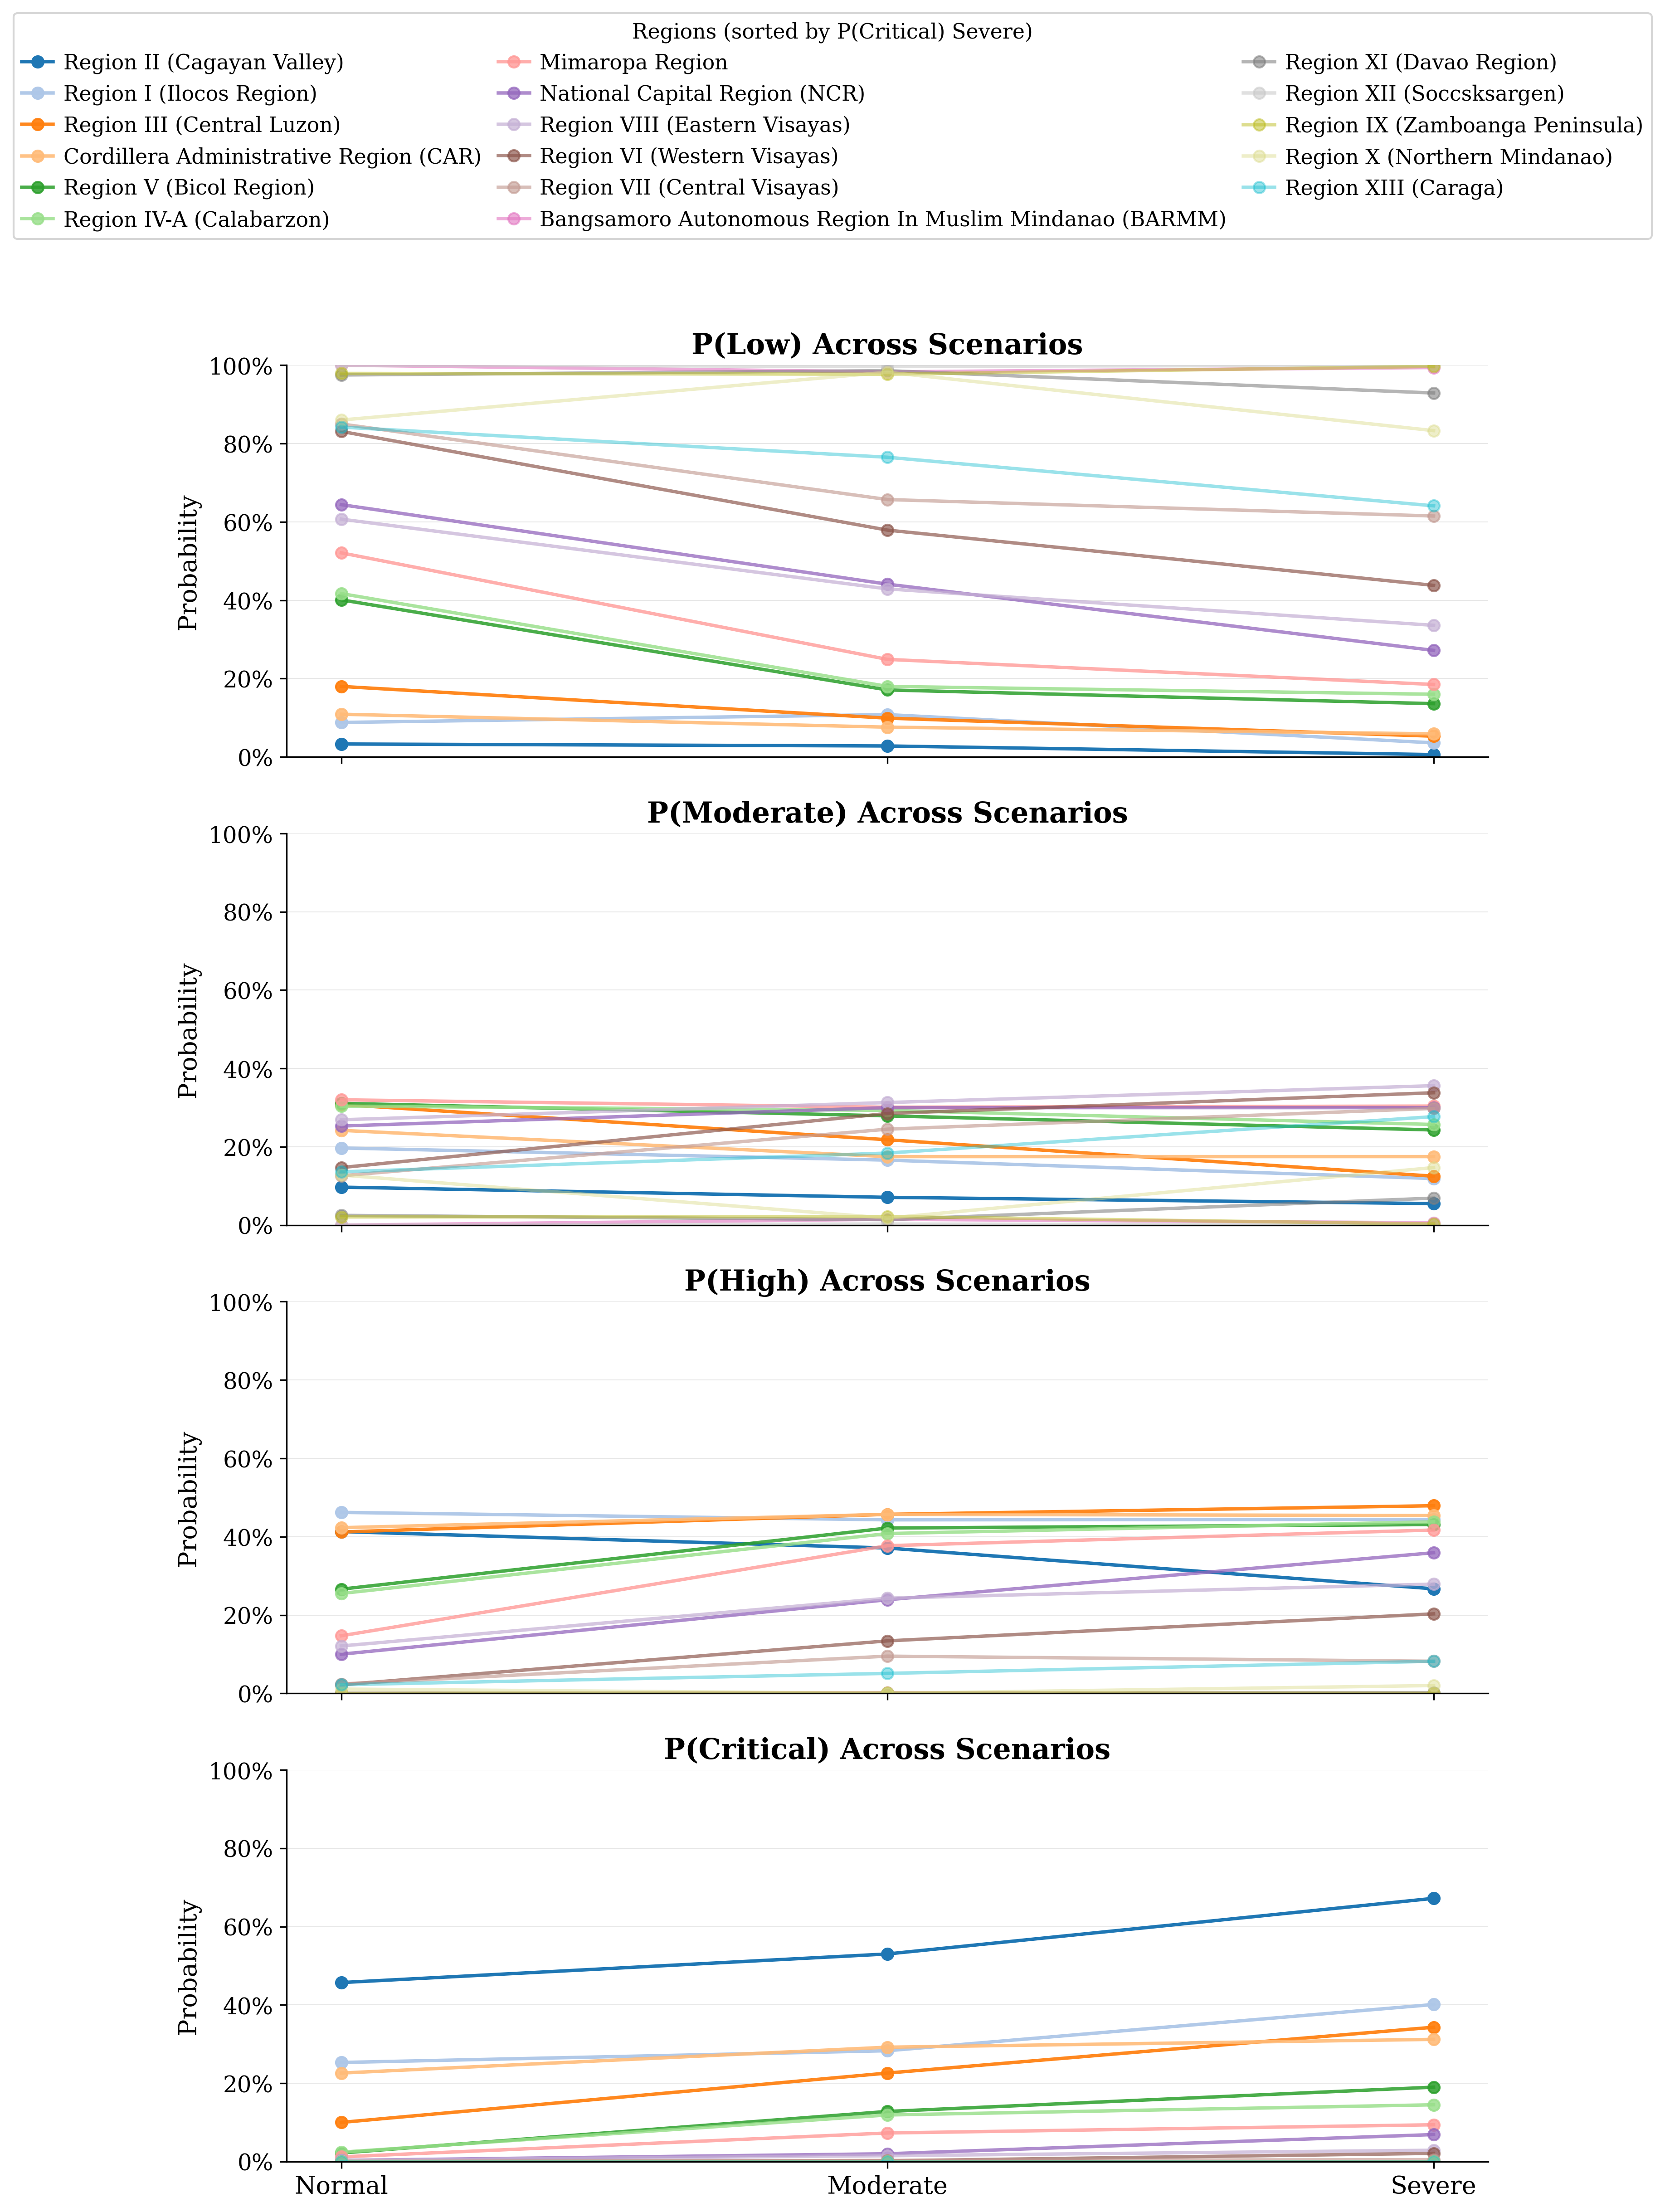

In [21]:
REGION_ABBREV = {
    'Region I Ilocos':                          'R1 Ilocos',
    'Region II Cagayan Valley':                 'R2 Cagayan',
    'Region III Central Luzon':                 'R3 C.Luzon',
    'Region IV-A Calabarzon':                   'R4A Calabarzon',
    'MIMAROPA Region':                          'R4B MIMAROPA',
    'Region V Bicol':                           'R5 Bicol',
    'Region VI Western Visayas':                'R6 W.Visayas',
    'Region VII Central Visayas':               'R7 C.Visayas',
    'Region VIII Eastern Visayas':              'R8 E.Visayas',
    'Region IX Zamboanga Peninsula':            'R9 Zamboanga',
    'Region X Northern Mindanao':               'R10 N.Mindanao',
    'Region XI Davao':                          'R11 Davao',
    'Region XII Soccsksargen':                  'R12 SOCCSKSARGEN',
    'Region XIII Caraga':                       'R13 Caraga',
    'National Capital Region':                  'NCR',
    'Cordillera Administrative Region':         'CAR',
    'Bangsamoro Autonomous Region in Muslim Mindanao': 'BARMM',
}

SCENARIOS   = ['Normal', 'Moderate', 'Severe']
RISK_COLS   = ['p_low', 'p_moderate', 'p_high', 'p_critical']
RISK_LABELS = ['Low', 'Moderate', 'High', 'Critical']
COLORS      = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

region_order = (
    results_df[results_df['scenario'] == 'Severe']
    .sort_values('p_critical', ascending=False)
    ['region'].tolist()
)
n_regions = len(region_order)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 13,
})

fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True, dpi=300)

for ax, risk_col, risk_label, color in zip(axes, RISK_COLS, RISK_LABELS, COLORS):
    for i, region in enumerate(region_order):
        region_data = results_df[results_df['region'] == region]
        values = [
            region_data[region_data['scenario'] == s][risk_col].values[0]
            for s in SCENARIOS
        ]
        short_label = REGION_ABBREV.get(region, region)
        ax.plot(
            SCENARIOS, values,
            marker='o',
            markersize=6,
            linewidth=1.8,
            alpha=1.0 - (i / n_regions) * 0.6,
            label=short_label,
            color=plt.cm.tab20(i / n_regions)
        )

    ax.set_title(
        f'P({risk_label}) Across Scenarios',
        fontsize=15, fontweight='bold', pad=6
    )
    ax.set_ylabel('Probability', fontsize=13, labelpad=4)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f'{y:.0%}')
    )
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

    if risk_label != 'Critical':
        ax.tick_params(axis='x', labelbottom=False)

axes[-1].tick_params(axis='x', labelsize=13)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='upper center',
    fontsize=11,
    ncol=3,
    framealpha=0.8,
    title='Regions (sorted by P(Critical) Severe)',
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    handlelength=1.5,
    columnspacing=0.8,
    handletextpad=0.5
)
plt.tight_layout(pad=1.0, h_pad=1.2, rect=[0, 0, 1, 0.88])
plt.savefig(
    '../results/03_scenario_comparison.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

Exposure Tier Bar Chart and Map

Exposure tier classification:
                                                 region  lambda_normal  lambda_moderate  lambda_severe  lambda_mean exposure_tier
                             Region II (Cagayan Valley)         5.5556           6.2222         7.8571       6.5450          High
                               Region I (Ilocos Region)         4.2222           4.4444         6.0000       4.8889          High
                 Cordillera Administrative Region (CAR)         4.1111           4.6667         5.1429       4.6402          High
                             Region III (Central Luzon)         3.3333           4.2222         5.1429       4.2328          High
                                Region V (Bicol Region)         2.3333           3.4444         4.2857       3.3545          High
                               Region IV-A (Calabarzon)         2.3333           3.3333         3.7143       3.1270          High
                                        Mimaropa Region     

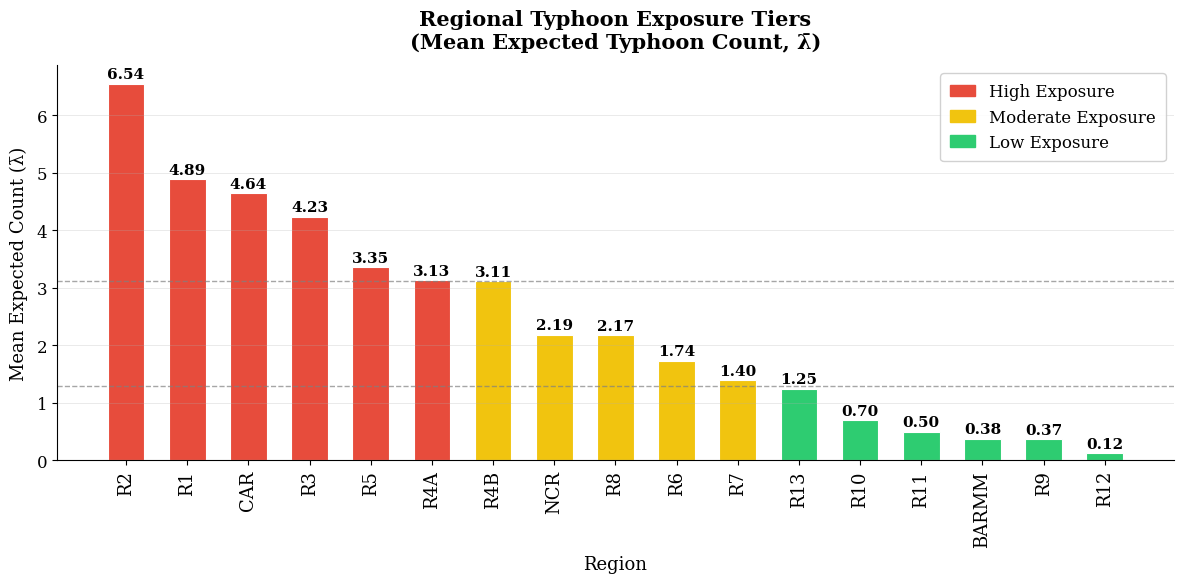

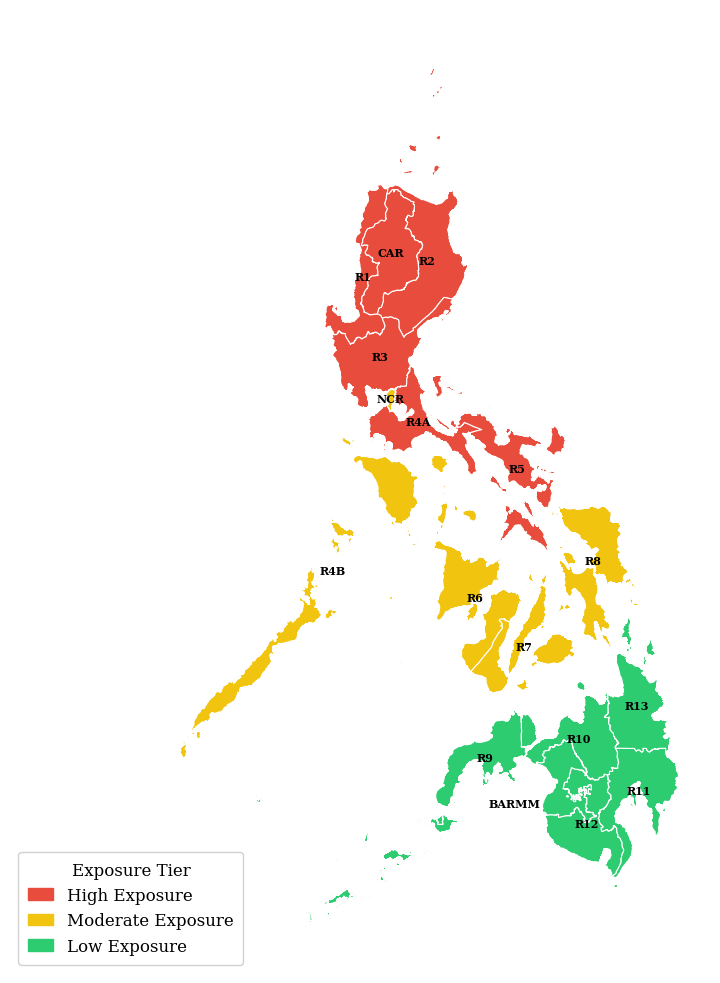

In [28]:
REGION_ABBREV = {
    'Region I (Ilocos Region)':                                'R1',
    'Region II (Cagayan Valley)':                              'R2',
    'Region III (Central Luzon)':                              'R3',
    'Region IV-A (Calabarzon)':                                'R4A',
    'Mimaropa Region':                                         'R4B',
    'Region V (Bicol Region)':                                 'R5',
    'Region VI (Western Visayas)':                             'R6',
    'Region VII (Central Visayas)':                            'R7',
    'Region VIII (Eastern Visayas)':                           'R8',
    'Region IX (Zamboanga Peninsula)':                         'R9',
    'Region X (Northern Mindanao)':                            'R10',
    'Region XI (Davao Region)':                                'R11',
    'Region XII (Soccsksargen)':                               'R12',
    'Region XIII (Caraga)':                                    'R13',
    'National Capital Region (NCR)':                           'NCR',
    'Cordillera Administrative Region (CAR)':                  'CAR',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}

lambda_wide = params_df.pivot_table(
    index='region',
    columns='scenario',
    values='lambda'
).reset_index()

lambda_wide.columns.name = None
lambda_wide = lambda_wide.rename(columns={
    'Normal':   'lambda_normal',
    'Moderate': 'lambda_moderate',
    'Severe':   'lambda_severe'
})

lambda_wide['lambda_mean'] = (
    lambda_wide[['lambda_normal', 'lambda_moderate', 'lambda_severe']]
    .mean(axis=1)
    .round(4)
)
lambda_wide['exposure_tier'] = pd.qcut(
    lambda_wide['lambda_mean'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)
lambda_wide = lambda_wide.sort_values('lambda_mean', ascending=False)

print('Exposure tier classification:')
print(lambda_wide[['region', 'lambda_normal', 'lambda_moderate',
                    'lambda_severe', 'lambda_mean', 'exposure_tier']]
      .to_string(index=False))

TIER_COLORS = {
    'Low':      '#2ecc71',
    'Moderate': '#f1c40f',
    'High':     '#e74c3c'
}

short_regions = lambda_wide['region'].map(REGION_ABBREV).tolist()

legend_patches = [
    mpatches.Patch(color=TIER_COLORS[t], label=f'{t} Exposure')
    for t in ['High', 'Moderate', 'Low']
]

fig, ax = plt.subplots(figsize=(12, 6))

x = list(range(len(lambda_wide)))
colors = lambda_wide['exposure_tier'].map(TIER_COLORS).tolist()

bars = ax.bar(
    x,
    lambda_wide['lambda_mean'].tolist(),
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(short_regions, rotation=90, ha='center', fontsize=13)

for bar, val in zip(bars, lambda_wide['lambda_mean']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

tercile_bounds = lambda_wide['lambda_mean'].quantile([0.33, 0.67]).values
for bound in tercile_bounds:
    ax.axhline(bound, color='gray', linestyle='--', linewidth=1.0, alpha=0.7)

ax.legend(
    handles=legend_patches,
    fontsize=12, framealpha=0.9,
    loc='upper right',
    handlelength=1.5,
    borderpad=0.6
)
ax.set_title(
    'Regional Typhoon Exposure Tiers\n(Mean Expected Typhoon Count, λ̄)',
    fontsize=15, fontweight='bold', pad=12
)
ax.set_xlabel('Region', fontsize=13, labelpad=6)
ax.set_ylabel('Mean Expected Count (λ̄)', fontsize=13, labelpad=6)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.6)

plt.tight_layout(pad=1.0)
plt.savefig(
    '../results/04a_exposure_tier_bar.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

map_tiers = regions_gdf.merge(
    lambda_wide[['region', 'exposure_tier', 'lambda_mean']],
    on='region', how='left'
)
map_tiers['color'] = map_tiers['exposure_tier'].map(TIER_COLORS)

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

map_tiers.plot(
    color=map_tiers['color'],
    linewidth=0.8,
    edgecolor='white',
    ax=ax
)

for _, row in map_tiers.iterrows():
    centroid = row.geometry.centroid
    label = REGION_ABBREV.get(row['region'], row['region'])
    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=8, color='black',
        fontweight='bold',
        linespacing=1.2
    )

ax.legend(
    handles=legend_patches,
    title='Exposure Tier',
    loc='lower left',
    fontsize=12,
    title_fontsize=12,
    framealpha=0.9,
    handlelength=1.5,
    borderpad=0.6
)

ax.set_axis_off()
plt.tight_layout(pad=1.0)
plt.savefig(
    '../results/04b_exposure_tier_map.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

lambda_wide.to_csv('../data_clean/exposure_tiers.csv', index=False)